<a href="https://colab.research.google.com/github/sayandeepmaity/luminator/blob/main/guntype_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
import pandas as pd

# Load Model 2 data
train_data_model2 = pd.read_csv('/content/drive/My Drive/gunshotdata/dmodel2/train_data_model2.csv')
test_data_model2 = pd.read_csv('/content/drive/My Drive/gunshotdata/dmodel2/test_data_model2.csv')

# Define a mapping from label to gun name (example mapping, should be updated based on actual classes)
label_to_gunname = {
    0: 'Pistol',
    1: 'Rifle',
    2: 'Shotgun',
    3: 'Revolver',
    4: 'SMG',
    5: 'Assault Rifle'
}

# Map labels to gun names
train_data_model2['gun_name'] = train_data_model2['label'].map(label_to_gunname)
test_data_model2['gun_name'] = test_data_model2['label'].map(label_to_gunname)

# Save updated datasets to Model 3 paths
train_path_model3 = '/content/drive/My Drive/gunshotdata/dmodel3/train_data_model3.csv'
test_path_model3 = '/content/drive/My Drive/gunshotdata/dmodel3/test_data_model3.csv'

train_data_model2.to_csv(train_path_model3, index=False)
test_data_model2.to_csv(test_path_model3, index=False)

train_path_model3, test_path_model3

# Print a preview of the new 'gun_name' column in both datasets
print("Unique gun names in training data:", train_data_model2['gun_name'].unique())
print("Unique gun names in testing data:", test_data_model2['gun_name'].unique())

# Optionally, preview first few rows
print("\nTraining data sample:")
print(train_data_model2[['label', 'gun_name']].head())

print("\nTesting data sample:")
print(test_data_model2[['label', 'gun_name']].head())



Unique gun names in training data: ['Rifle' 'Pistol']
Unique gun names in testing data: ['Pistol' 'Rifle']

Training data sample:
   label gun_name
0    1.0    Rifle
1    0.0   Pistol
2    0.0   Pistol
3    0.0   Pistol
4    0.0   Pistol

Testing data sample:
   label gun_name
0    0.0   Pistol
1    1.0    Rifle
2    1.0    Rifle
3    0.0   Pistol
4    1.0    Rifle


In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib  # For saving the model

# Load the data for Model 3
train_data_model3 = pd.read_csv('/content/drive/My Drive/gunshotdata/dmodel3/train_data_model3.csv')
test_data_model3 = pd.read_csv('/content/drive/My Drive/gunshotdata/dmodel3/test_data_model3.csv')

# Define features and target
features = [
    'spectral_centroid', 'amplitude', 'energy',  # Spectral features
    'tau_01', 'tau_02', 'tau_03', 'tau_04', 'tau_05', 'tau_12', 'tau_13', 'tau_14', 'tau_15', 'tau_23', 'tau_24', 'tau_25',
    'tau_34', 'tau_35', 'tau_45',  # Localization features (tau)
    'corr_01', 'corr_02', 'corr_03', 'corr_04', 'corr_05', 'corr_12', 'corr_13', 'corr_14', 'corr_15', 'corr_23', 'corr_24', 'corr_25',
    'corr_34', 'corr_35', 'corr_45',  # Localization features (correlation)
    'snr', 'snr_01', 'snr_02', 'snr_03', 'snr_04', 'snr_05', 'snr_12', 'snr_13', 'snr_14', 'snr_15', 'snr_23', 'snr_24', 'snr_25',
    'snr_34', 'snr_35', 'snr_45'  # Signal-to-noise ratio (SNR)
]

# Extract features and labels from training and test datasets
X_train = train_data_model3[features]
y_train = train_data_model3['gun_name']
X_test = test_data_model3[features]
y_test = test_data_model3['gun_name']

# Split the data into training and validation sets
# (Just in case, let's hold out a validation set from the training data)
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train_split, y_train_split)

# Save the trained model
model_filename = '/content/drive/My Drive/gunshotdata/dmodel3/gun_type_model.pkl'
joblib.dump(rf_model, model_filename)

print(f"\nModel saved at: {model_filename}")



Model saved at: /content/drive/My Drive/gunshotdata/dmodel3/gun_type_model.pkl


Validation Accuracy: 0.996875

Confusion Matrix:
[[7973   28]
 [  22 7977]]

Classification Report:
              precision    recall  f1-score   support

      Pistol       1.00      1.00      1.00      8001
       Rifle       1.00      1.00      1.00      7999

    accuracy                           1.00     16000
   macro avg       1.00      1.00      1.00     16000
weighted avg       1.00      1.00      1.00     16000



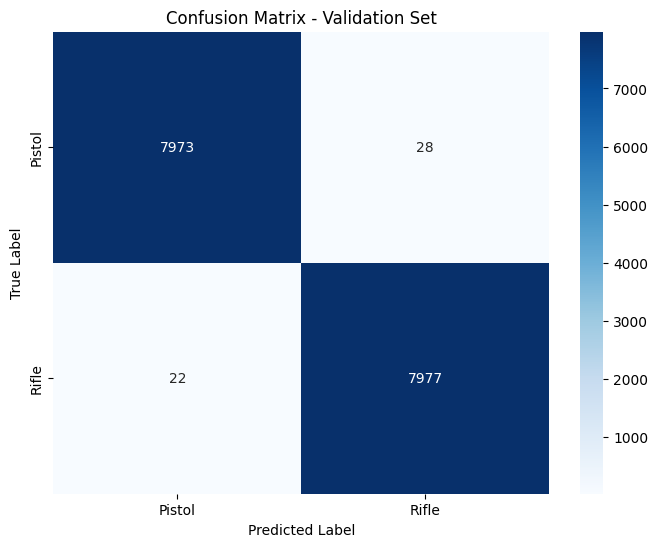


Test Accuracy: 0.99755

Test Classification Report:
              precision    recall  f1-score   support

      Pistol       1.00      1.00      1.00      9922
       Rifle       1.00      1.00      1.00     10078

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



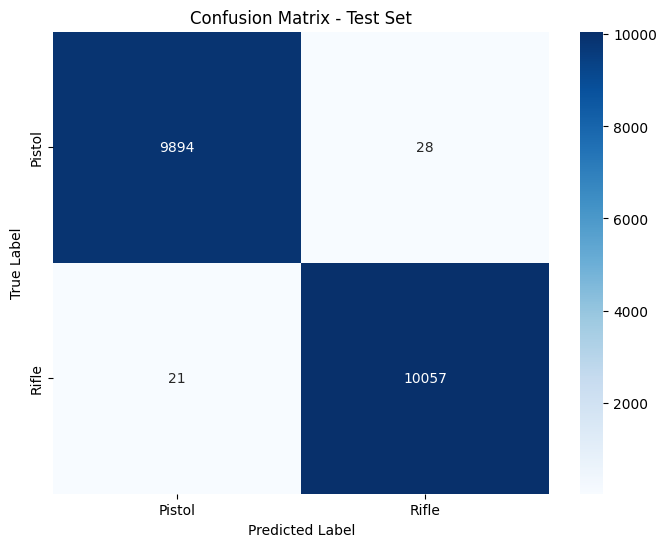

In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib  # For saving the model
import seaborn as sns  # For plotting the heatmap
import matplotlib.pyplot as plt  # For displaying the plot

# Load the data for Model 3
train_data_model3 = pd.read_csv('/content/drive/My Drive/gunshotdata/dmodel3/train_data_model3.csv')
test_data_model3 = pd.read_csv('/content/drive/My Drive/gunshotdata/dmodel3/test_data_model3.csv')

# Predictions on validation set
y_val_pred = rf_model.predict(X_val_split)

# Model evaluation: accuracy on the validation set
print("Validation Accuracy:", accuracy_score(y_val_split, y_val_pred))

# Confusion Matrix and Classification Report
print("\nConfusion Matrix:")
print(confusion_matrix(y_val_split, y_val_pred))

print("\nClassification Report:")
print(classification_report(y_val_split, y_val_pred))

# Visualizing the confusion matrix with a heatmap
cm = confusion_matrix(y_val_split, y_val_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Validation Set')
plt.show()

# Evaluate on the test data
y_test_pred = rf_model.predict(X_test)

# Test accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)
print("\nTest Accuracy:", test_accuracy)

print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred))

# Visualizing the confusion matrix for the test data
cm_test = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues", xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Test Set')
plt.show()